<a href="https://colab.research.google.com/github/anastasia-oleksandrivna-shevchenko/3course/blob/master/%D0%A8%D0%B5%D0%B2%D1%87%D0%B5%D0%BD%D0%BA%D0%BE_%22fashion_mnist_prevent_overfitting_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Аналіз якості роботи нейронної мережі для розпізнавання моделей одягу в Keras

Для того щоб запускати та редагувати код, збережіть копію цього ноутбука собі е (File->Save a copy in Drive...). Свою копію ви можете змінювати та запускати



In [12]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

## Підготовка даних для навчаня мережі

**Завантажуємо набір даних**

In [13]:
# В Keras вбудовані засоби роботи з популярним набором даних
# (x_train, y_train) - набір даних для навчання
# (x_test, y_test) - набір даних для тестування
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

 Список з назвами класів

In [14]:
classes = ['футболка', 'брюки', 'светр', 'плаття', 'пальто', 'туфлі', 'сорочка', 'кросівки', 'сумка', 'черевики']

 Переглянемо приклади зображень

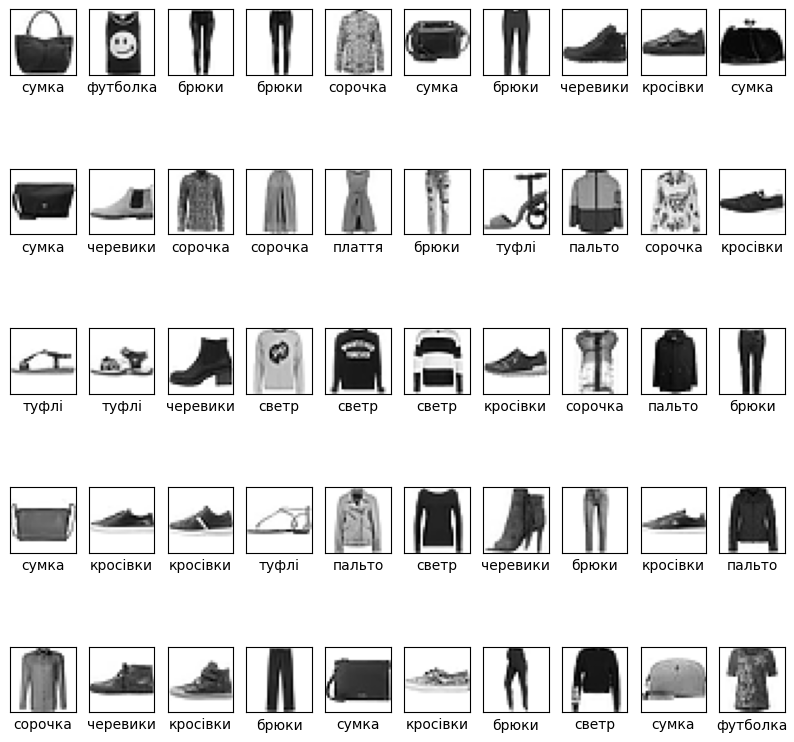

In [15]:
plt.figure(figsize=(10,10))
for i in range(100,150):
    plt.subplot(5,10,i-100+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(classes[y_train[i]])

**Перетворення розмірності зображень в наборі**

In [16]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

**Нормалізація даних**

In [17]:
# Вектаризовані операції
# Застосовуються до кожного елемент масиву окремо
x_train = x_train / 255
x_test = x_test / 255

**Робота з правильними відповідями**

In [18]:
n = 0

In [19]:
print(y_train[n])

9


**Перетворюємо мітки у категорії в формат one hot encoding**

In [20]:
y_train = utils.to_categorical(y_train, 10)

In [21]:
y_test = utils.to_categorical(y_test, 10)

**Правильна відповідь в форматі one hot encoding**

In [22]:
print(y_train[n])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


## Створюємо нейрону мережу

**Створюємо послідовну модель**

In [23]:
# Створюємо послідовну модель
model = Sequential()
# Вхідний повнов'язаний шар, 800 нейронів, 784 входи в кожен нейрон
model.add(Dense(1200, input_dim=784, activation="relu"))
model.add(Dense(900, activation="relu"))
# Вихідний повнозв'язаний шар, 10 нейронів (по кількості класів предметів одягу)
model.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Компілюємо мережу**

In [24]:
model.compile(loss="categorical_crossentropy", optimizer="SGD", metrics=["accuracy"])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1200)           │       942,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 900)            │     1,080,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,031,910 (7.75 MB)

 Trainable params: 2,031,910 (7.75 MB)

 Non-trainable params: 0 (0.00 B)

None


## Навчаємо нейрону мережу


In [25]:
history = model.fit(x_train, y_train,
                    batch_size=100,
                    epochs=100,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7155 - loss: 0.9488 - val_accuracy: 0.7922 - val_loss: 0.6500
Epoch 2/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8056 - loss: 0.5938 - val_accuracy: 0.8220 - val_loss: 0.5425
Epoch 3/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8243 - loss: 0.5230 - val_accuracy: 0.8304 - val_loss: 0.4983
Epoch 4/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8336 - loss: 0.4865 - val_accuracy: 0.8336 - val_loss: 0.4795
Epoch 5/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8399 - loss: 0.4640 - val_accuracy: 0.8369 - val_loss: 0.4617
Epoch 6/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8464 - loss: 0.4459 - val_accuracy: 0.8466 - val_loss: 0.4401
Epoch 7/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8500 - loss: 0.4320 - val_accuracy: 0.8428 - val_loss: 0.4457
Epoch 8/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8544 - loss: 0.4223 - val_accu

## Зберігаємо нейронну мережу для послідовного використання

In [26]:
model.save('fashion_mnist_dense.h5')

## Оцінка якості навчання

Перевірка якості роботи на наборі даних для тестування

In [ ]:
scores = model.evaluate(x_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8844 - loss: 0.3319


In [ ]:
print("Доля правильних відповідей на тестових даних, в відсотках:", round(scores[1] * 100, 4))

Доля правильних відповідей на тестових даних, в відсотках: 88.44


## Використовуємо мережу для розпізнавання предметів одежі

In [ ]:
n_rec = 493

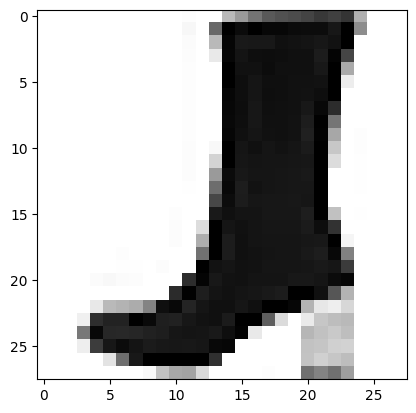

In [ ]:
plt.imshow(x_test[n_rec].reshape(28, 28), cmap=plt.cm.binary)
plt.show()

**Змінюємо розмірність зображення та нормалізуємо його**

In [ ]:
x = x_test[n_rec]
x = np.expand_dims(x, axis=0)

**Запускаємо розпізнавання**

In [ ]:
prediction = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


**Друкуємо результати розпізнавання**

In [ ]:
prediction

array([[6.6841034e-07, 6.5084458e-07, 5.7792170e-07, 7.7471867e-08,
        1.5713441e-09, 1.4297672e-03, 3.5017887e-08, 2.2803272e-06,
        2.7184437e-09, 9.9856591e-01]], dtype=float32)

**Перетворюємо результати із формату one hot encoding**

In [ ]:
prediction = np.argmax(prediction)
print("Номер класу:", prediction)
print("Назва класу:", classes[prediction])


Номер класу: 9
Назва класу: черевики


**Друкуємо правильну відповідь**

In [ ]:
label = np.argmax(y_test[n_rec])
print("Номер класу:", label)
print("Назва класу:", classes[label])

Номер класу: 9
Назва класу: черевики


## Завантажуємо свою картинку
Натиснути кнопку "Вибрати файли" та завантажити зображення з диску

In [ ]:
files.upload()

Saving Знімок екрана 2026-09-16 150637.png to Знімок екрана 2026-09-16 150637.png


{'Знімок екрана 2026-09-16 150637.png': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02x\x00\x00\x038\x08\x06\x00\x00\x00_\xb8\x9f\xe2\x00\x00\x00\x01sRGB\x00\xae\xce\x1c\xe9\x00\x00\x00\x04gAMA\x00\x00\xb1\x8f\x0b\xfca\x05\x00\x00\x00\tpHYs\x00\x00\x1d\x87\x00\x00\x1d\x87\x01\x8f\xe5\xf1e\x00\x00\xff\xa5IDATx^\xec\xfdY\x93l\xe9u\xa6\x07.?S\x0e\x00\x88\x81\x04Y$\xc1\x02\x8a,\x16\x8b\x14\xa7\xee*\x822\x99\xc9d\xba\x91d\xd6\xd6}\xa1\x1b\xfd\x826\xeb\xfe\x17\xfd/\xba\xcd\xfag\xe8B\xea\x1b\xb5.\xd4*#e*\x12\xa4j\x90\xc8*\x12d\x95\x08\x12\x03\x89\x9c\x90\'\xcf\xe0}\x11g%V>\xf1\xae\xe1\xdb{{x$p\x1e3\xb7\x88oM\xefZko\xf7\xf4\xf4\x13q\xce\xe9\xd7\x7f\xf3w\xce\xf6\x8a?\xfe\xc6\xef\xfb\xb7\x87r>\x9f\xedt:\xd1|\'\xacj\xaf\xc6W\x9c\xcf7\xab=\xaa\xde\n\xd7\xd4\xb6\r{\\\x8d\xaf\xb8\xe6\xec\xd7\xd4\xb6\x83\xf7\xb8\xca5g\xbf\xa6\xb6s\xed\xdd\xafh\xaf\xc6W\\s\xf7\xd7\xd4\xb6\r{\\\x8d\xaf\xb8\xe6\xec\xd7\xd4\xb6\x83\xf7\xb8\xca5g\x9fj\xff\xc6o}\xdd\xcc\xcc\x1e\xd0a\xaf\x8ax!\x05}<;^\x87\xcd\xb8]\xe5U>\

Перевіряємо завантаження картинки

In [ ]:
!ls

 fashion_mnist_dense.h5   sample_data  'Знімок екрана 2026-09-16 150637.png'


Завантажуємо картинку з файлу

In [ ]:
img_path = 'Знімок екрана 2026-09-16 150637.png'
img = image.load_img(img_path, target_size=(28, 28), color_mode = "grayscale")

Показуємо картинку

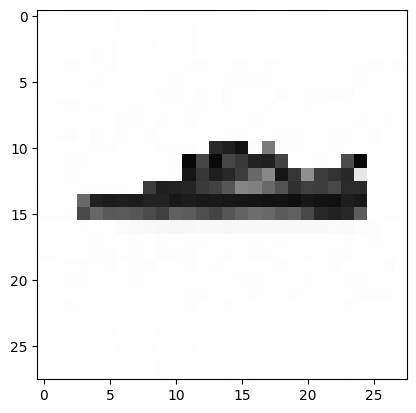

In [ ]:
plt.imshow(img.convert('RGBA'))
plt.show()

Перетворюємо картинку для обробки нейронів нейронно мережою

In [ ]:
# Перетворюємо зображення в масив
x = image.img_to_array(img)
# Змінюємо форму масиву в плаский вектор
x = x.reshape(1, 784)
# Інвертуємо зображення
x = 255 - x
# Нормалізуємо зображення
x = x/255

Запускаємо розпізнавання

In [ ]:
prediction = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


Результати розпізнавання

In [ ]:
prediction

array([[4.7962839e-04, 4.2376135e-04, 2.0077049e-03, 3.4457303e-04,
        1.5002245e-04, 1.3477290e-01, 1.4268267e-05, 8.6016840e-01,
        1.5938419e-03, 4.4906625e-05]], dtype=float32)

In [ ]:
prediction = np.argmax(prediction)
print("Номер класу:", prediction)
print("Назва класу:", classes[prediction])

Номер класу: 7
Назва класу: кросівки


## Ідеї по зміні архітектури нейронної мережі

1. Спробуйте використати різну кількість нейронів на вхідному шарі: 400, 600, 800, 1200.
2. Додайте в нейронну мережу прихований шар з різною кількістю нейронів: 200, 300, 400, 600, 800.
3. Додайте декілька прихованих шарів в мережу з різною кількістю нейронів в кожому шарі.
3. Використайте різну кількість епох: 10, 15, 20, 25, 30.
4. Використайте різні розміри міні-вибірки (batch_size): 10, 50, 100, 200, 500.


Підберіть різні комбінації гіперпараметрів таким чином, щоб отримати кращий результат на тестовому наборі даних.

Переконайтесь, що в вашій моделі немає перенавчання.